<a href="https://colab.research.google.com/github/rkikkeri/ML-DL/blob/main/GNN_based_F_Fond_HS_binding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile fondaparinux_gnn_screen.py
"""
Fondaparinux-derivative GNN + BioBERT/SciBERT/ProtBERT screening pipeline

Goal:
1. Define three fondaparinux-based derivatives.
2. Convert molecules into graph structures.
3. Generate GNN molecular embeddings.
4. Compare each derivative against a broad protein panel.
5. Use protein sequence features + ProtBERT embeddings.
6. Use BioBERT, SciBERT, and ChemBERTa-style text/SMILES models for behavior evidence.
7. Rank protein targets by predicted binding affinity score.
8. Export final top-15 protein ranking and full results to Excel.

Important:
This is a computational prioritization workflow, not validated binding data.
Use SPR, BLI, ITC, ELISA, docking, or MD to experimentally validate predictions.
"""


In [2]:
import sys
import subprocess
import os

def install_package(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

packages = [
    "rdkit",
    "torch",
    "torch-geometric",
    "transformers",
    "sentencepiece",
    "accelerate",
    "pandas",
    "numpy",
    "scikit-learn",
    "openpyxl",
    "xlsxwriter",
    "requests",
    "tqdm",
    "biopython"
]

for pkg in packages:
    try:
        install_package(pkg)
    except Exception as e:
        print(f"Could not install {pkg}: {e}")

In [3]:

# ============================================================
# 1. Imports
# ============================================================

import math
import json
import time
import random
import warnings
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, Draw
from rdkit.Chem.rdchem import HybridizationType

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")



In [4]:

# ============================================================
# 2. Global configuration
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

OUTPUT_EXCEL = "fondaparinux_derivative_protein_ranking.xlsx"
STRUCTURE_DIR = "compound_structures"
os.makedirs(STRUCTURE_DIR, exist_ok=True)

USE_LARGE_LANGUAGE_MODELS = True
MAX_SEQUENCE_LENGTH = 1024

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


Using device: cpu


In [5]:

# ============================================================
# 3. Define four fondaparinux-based derivatives
# ============================================================
"""
Replace these placeholder SMILES with your exact fondaparinux derivatives.

Notes:
- Fondaparinux is a highly sulfated pentasaccharide.
- Full chemically exact sulfated carbohydrate SMILES can be long and difficult.
- RDKit may reject unusual salt/protonation forms if malformed.
- For real work, use curated canonical SMILES or MOL/SDF files.
"""

COMPOUNDS = [
    {
        "compound_id": "L-1",
        "description": "Fondaparinux-like sulfated pentasaccharide analog; placeholder structure",
        "smiles": "O[C@H]1[C@H](O)[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](F)[C@@H](O)[C@H](O[C@@H]([C@H](OSOO[O-])[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](O)[C@H]2OSOO[O-])[C@H](C(O)=O)O[C@H]2O[C@H]3C(O)[C@@H](N=SOO[O-])[C@@H](OC)O[C@@H]3COS(=O)([O-])=O)O4)[C@H]4COS(=O)([O-])=O)O5)[C@H]5C(O)=O)O[C@@H]1COS(=O)([O-])=O"
    },
    {
        "compound_id": "L-2",
        "description": "Fluorinated fondaparinux-like sulfated analog; placeholder structure",
        "smiles": "O[C@H]1[C@H](O)[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](O)[C@@H](O)[C@H](O[C@@H]([C@H](OSOO[O-])[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](O)[C@H]2OSOO[O-])[C@H](C(O)=O)O[C@H]2O[C@H]3C(O)[C@@H](N=SOO[O-])[C@@H](OC)O[C@@H]3COS(=O)([O-])=O)O4)[C@H]4COS(=O)([O-])=O)O5)[C@H]5C(O)=O)O[C@@H]1COS(=O)([O-])=O"
    },
    {
        "compound_id": "L-3",
        "description": "More highly sulfated fondaparinux-like analog; placeholder structure",
        "smiles": "O[C@H]1[C@H](O)[C@@H](NC(C)=O)[C@@H](O[C@@H]([C@H](F)[C@@H](O)[C@H](O[C@@H]([C@H](OSOO[O-])[C@@H](NC(C)=O)[C@@H](O[C@@H]([C@H](O)[C@H]2OSOO[O-])[C@H](C(O)=O)O[C@H]2O[C@H]3C(O)[C@@H](NC(C)=O)[C@@H](OC)O[C@@H]3COS(=O)([O-])=O)O4)[C@H]4COS(=O)([O-])=O)O5)[C@H]5C(O)=O)O[C@@H]1COS(=O)([O-])=O"
    },
    {
        "compound_id": "L-4",
        "description": "More highly sulfated fondaparinux-like analog; placeholder structure",
        "smiles": "O[C@H]1[C@H](O)[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](O)[C@@H](O)[C@H](O[C@@H]([C@H](OSOO[O-])[C@@H](N=SOO[O-])[C@@H](O[C@@H]([C@H](O)[C@H]2OSOO[O-])[C@H](C(O)=O)O[C@H]2O[C@H]3C(O)[C@@H](N=SOO[O-])[C@@H](OC4=CC=C(C(F)(F)F)C=C4)O[C@@H]3COS(=O)([O-])=O)O5)[C@H]5COS(=O)([O-])=O)O6)[C@H]6C(O)=O)O[C@@H]1COS(=O)([O-])=O"
    }
]


In [24]:

# ============================================================
# 4.  Blood coagulation protein panel
# ============================================================
"""
Panel includes coagulation and glycan-binding proteins.
"""

PROTEIN_PANEL = [
    {"gene": "SERPINC1", "name": "Antithrombin III", "uniprot": "P01008", "prior": 1.00, "category": "coagulation"},
    {"gene": "F10", "name": "Factor Xa", "uniprot": "P00742", "prior": 0.88, "category": "coagulation"},
    {"gene": "F2", "name": "Thrombin / Prothrombin", "uniprot": "P00734", "prior": 0.70, "category": "coagulation"},
    {"gene": "TFPI", "name": "Tissue factor pathway inhibitor", "uniprot": "P10646", "prior": 0.65, "category": "coagulation"},
    {"gene": "SERPINA5", "name": "Protein C inhibitor", "uniprot": "P05154", "prior": 0.62, "category": "coagulation"},
    {"gene": "F9", "name": "Factor IX", "uniprot": "P00740", "prior": 0.58, "category": "coagulation"},
    {"gene": "F11", "name": "Factor XI", "uniprot": "P03951", "prior": 0.56, "category": "coagulation"},
    {"gene": "F12", "name": "Factor XII", "uniprot": "P00748", "prior": 0.54, "category": "coagulation"},
    {"gene": "PROC", "name": "Protein C", "uniprot": "P04070", "prior": 0.45, "category": "coagulation"},
    {"gene": "PROS1", "name": "Protein S", "uniprot": "P07225", "prior": 0.44, "category": "coagulation"},
    {"gene": "F8", "name": "Factor VIII", "uniprot": "P00451", "prior": 0.43, "category": "coagulation"},
    {"gene": "F5", "name": "Factor V", "uniprot": "P12259", "prior": 0.42, "category": "coagulation"},
    {"gene": "F7", "name": "Factor VII", "uniprot": "P08709", "prior": 0.41, "category": "coagulation"},
    {"gene": "FGA", "name": "Fibrinogen alpha chain", "uniprot": "P02671", "prior": 0.35, "category": "coagulation"},
    {"gene": "PLAT", "name": "Tissue plasminogen activator", "uniprot": "P00750", "prior": 0.34, "category": "coagulation"}
]


In [25]:

# ============================================================
# 5. Molecule utilities
# ============================================================

def mol_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return mol

def compute_molecular_descriptors(smiles):
    mol = mol_from_smiles(smiles)

    descriptors = {
        "mol_weight": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "tpsa": Descriptors.TPSA(mol),
        "hbd": Descriptors.NumHDonors(mol),
        "hba": Descriptors.NumHAcceptors(mol),
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol),
        "ring_count": Descriptors.RingCount(mol),
        "formal_charge": Chem.GetFormalCharge(mol),
        "sulfate_like_count": len(mol.GetSubstructMatches(Chem.MolFromSmarts("S(=O)(=O)O"))),
        "oxygen_count": sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "O"),
        "fluorine_count": sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "F"),
        "heavy_atom_count": mol.GetNumHeavyAtoms()
    }

    descriptors["negative_charge_proxy"] = (
        descriptors["sulfate_like_count"] * 1.0
        + max(0, -descriptors["formal_charge"])
        + 0.05 * descriptors["oxygen_count"]
    )

    descriptors["polarity_proxy"] = descriptors["tpsa"] / max(descriptors["heavy_atom_count"], 1)

    return descriptors

def save_molecule_image(smiles, compound_id):
    mol = mol_from_smiles(smiles)
    img_path = os.path.join(STRUCTURE_DIR, f"{compound_id}.png")
    Draw.MolToFile(mol, img_path, size=(500, 400))
    return img_path


In [26]:

# ============================================================
# 6. Convert molecule to graph for GNN
# ============================================================

ATOM_LIST = ["C", "N", "O", "S", "F", "P", "Cl", "Br", "I", "H", "Other"]

def atom_feature_vector(atom):
    symbol = atom.GetSymbol()
    symbol_id = ATOM_LIST.index(symbol) if symbol in ATOM_LIST else ATOM_LIST.index("Other")

    features = [
        symbol_id,
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs()
    ]
    return features

def bond_feature_vector(bond):
    bt = bond.GetBondType()
    return [
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

def mol_to_graph(smiles):
    mol = mol_from_smiles(smiles)

    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(atom_feature_vector(atom))

    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_feature_vector(bond)

        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_attr.append(bf)
        edge_attr.append(bf)

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)



In [27]:

# ============================================================
# 7. GNN molecular encoder
# ============================================================

class MolecularGNN(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=128, output_dim=128):
        super().__init__()
        self.atom_proj = nn.Linear(input_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x.to(DEVICE), data.edge_index.to(DEVICE)

        h = F.relu(self.atom_proj(x))
        h = F.relu(self.conv1(h, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        h = F.relu(self.conv3(h, edge_index))

        batch = torch.zeros(h.shape[0], dtype=torch.long, device=DEVICE)
        pooled = global_mean_pool(h, batch)

        return self.out(pooled)


In [28]:

# ============================================================
# 8. UniProt sequence fetching
# ============================================================

def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    try:
        response = requests.get(url, timeout=20)
        if response.status_code != 200:
            return None

        lines = response.text.strip().split("\n")
        seq = "".join([line.strip() for line in lines if not line.startswith(">")])
        return seq if len(seq) > 0 else None
    except Exception:
        return None



In [29]:

# ============================================================
# 9. Protein basic/HS-binding features
# ============================================================

def protein_sequence_features(seq):
    if seq is None or len(seq) == 0:
        return {
            "seq_length": 0,
            "basic_fraction": 0,
            "acidic_fraction": 0,
            "lys_arg_count": 0,
            "heparin_motif_count": 0,
            "cys_fraction": 0,
            "aromatic_fraction": 0
        }

    seq = seq.upper()
    n = len(seq)

    basic = seq.count("K") + seq.count("R") + seq.count("H")
    acidic = seq.count("D") + seq.count("E")
    lys_arg = seq.count("K") + seq.count("R")
    cys = seq.count("C")
    aromatic = seq.count("F") + seq.count("Y") + seq.count("W")

    motifs = 0
    for i in range(0, max(0, n - 4)):
        window = seq[i:i+5]
        if window.count("K") + window.count("R") >= 3:
            motifs += 1

    return {
        "seq_length": n,
        "basic_fraction": basic / n,
        "acidic_fraction": acidic / n,
        "lys_arg_count": lys_arg,
        "heparin_motif_count": motifs,
        "cys_fraction": cys / n,
        "aromatic_fraction": aromatic / n
    }


In [30]:


# ============================================================
# 10. Transformer embedding utilities
# ============================================================

class MeanPoolTransformer:
    def __init__(self, model_name, max_length=512):
        self.model_name = model_name
        self.max_length = max_length
        print(f"Loading model: {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()

    def encode(self, text):
        try:
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=self.max_length
            )
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)

            hidden = outputs.last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            return pooled.squeeze(0).detach().cpu().numpy()

        except Exception as e:
            print(f"Embedding failed for {self.model_name}: {e}")
            return None


def cosine_similarity(a, b):
    if a is None or b is None:
        return 0.0
    a = np.array(a)
    b = np.array(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)



In [31]:

# ============================================================
# 11. Load language models
# ============================================================

if USE_LARGE_LANGUAGE_MODELS:
    try:
        biobert_encoder = MeanPoolTransformer(
            "dmis-lab/biobert-base-cased-v1.1",
            max_length=256
        )
    except Exception:
        biobert_encoder = None

    try:
        scibert_encoder = MeanPoolTransformer(
            "allenai/scibert_scivocab_uncased",
            max_length=256
        )
    except Exception:
        scibert_encoder = None

    try:
        chemberta_encoder = MeanPoolTransformer(
            "DeepChem/ChemBERTa-77M-MTR",
            max_length=256
        )
    except Exception:
        chemberta_encoder = None

    try:
        protbert_encoder = MeanPoolTransformer(
            "Rostlab/prot_bert",
            max_length=MAX_SEQUENCE_LENGTH
        )
    except Exception:
        protbert_encoder = None
else:
    biobert_encoder = None
    scibert_encoder = None
    chemberta_encoder = None
    protbert_encoder = None



Loading model: dmis-lab/biobert-base-cased-v1.1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model: allenai/scibert_scivocab_uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                             | Status     | 
--------------------------------+------------+-
regression.dense.weight         | UNEXPECTED | 
regression.out_proj.weight      | UNEXPECTED | 
norm_mean                       | UNEXPECTED | 
regression.dense.bias           | UNEXPECTED | 
regression.out_proj.bias        | UNEXPECTED | 
norm_std                        | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading model: Rostlab/prot_bert


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:

# ============================================================
# 12. Protein sequence embedding
# ============================================================

def prepare_protein_sequence_for_protbert(seq):
    if seq is None:
        return ""
    seq = seq[:MAX_SEQUENCE_LENGTH]
    return " ".join(list(seq))

def get_protein_embedding(seq):
    if protbert_encoder is None or seq is None:
        return None
    formatted = prepare_protein_sequence_for_protbert(seq)
    return protbert_encoder.encode(formatted)


In [33]:

# ============================================================
# 13. Literature behavior score using BioBERT/SciBERT
# ============================================================

def get_literature_text_for_pair(compound_description, protein_name, gene):
    """
    Lightweight text representation.
    For a stronger version, replace this with PubMed abstract retrieval.
    """
    text = (
        f"{compound_description}. Protein target: {protein_name} ({gene}). "
        f"Potential heparin, fondaparinux, sulfated glycosaminoglycan, "
        f"anticoagulant, inflammation, cytokine, coagulation, complement, "
        f"growth factor, chemokine, receptor binding, immune modulation behavior."
    )
    return text

def literature_behavior_score(compound_description, protein_name, gene):
    query = (
        "fondaparinux heparin sulfated glycosaminoglycan protein binding "
        "anticoagulant immune modulation high affinity"
    )

    text = get_literature_text_for_pair(compound_description, protein_name, gene)

    scores = []

    if biobert_encoder is not None:
        q_emb = biobert_encoder.encode(query)
        t_emb = biobert_encoder.encode(text)
        scores.append(cosine_similarity(q_emb, t_emb))

    if scibert_encoder is not None:
        q_emb = scibert_encoder.encode(query)
        t_emb = scibert_encoder.encode(text)
        scores.append(cosine_similarity(q_emb, t_emb))

    if len(scores) == 0:
        return 0.0

    return float(np.mean(scores))



In [34]:

# ============================================================
# 14. ChemBERTa SMILES behavior score
# ============================================================

def chemberta_similarity_score(smiles):
    if chemberta_encoder is None:
        return 0.0

    query = "sulfated glycosaminoglycan fondaparinux heparin anticoagulant"
    smi_emb = chemberta_encoder.encode(smiles)
    q_emb = chemberta_encoder.encode(query)
    return cosine_similarity(smi_emb, q_emb)


In [35]:

# ============================================================
# 15. Binding score model
# ============================================================
"""
This score combines:
- GNN molecular embedding
- molecular charge/sulfation features
- protein basic residue enrichment
- heparin-binding motif count
- category prior
- BioBERT/SciBERT literature behavior
- ChemBERTa compound behavior

If you have real Kd/IC50 data, replace this scoring block with supervised training.
"""

CATEGORY_PRIOR = {
    "coagulation": 0.90,
    "chemokine": 0.75,
    "growth_factor": 0.72,
    "complement": 0.65,
    "lectin": 0.62,
    "siglec": 0.55,
    "innate_immunity": 0.55,
    "cytokine": 0.45,
    "adhesion": 0.48,
    "metabolism": 0.50,
    "extracellular_matrix": 0.60,
    "proteoglycan": 0.58,
    "covid_host": 0.40
}

def normalize_value(x, low, high):
    if high == low:
        return 0.0
    return max(0.0, min(1.0, (x - low) / (high - low)))

def compute_binding_score(
    mol_desc,
    protein_features,
    category,
    literature_score,
    chemberta_score,
    gnn_similarity
):
    negative_charge = normalize_value(mol_desc["negative_charge_proxy"], 0, 8)
    sulfate = normalize_value(mol_desc["sulfate_like_count"], 0, 5)
    tpsa = normalize_value(mol_desc["tpsa"], 0, 350)

    basic_fraction = normalize_value(protein_features["basic_fraction"], 0.04, 0.18)
    motif_score = normalize_value(protein_features["heparin_motif_count"], 0, 20)

    prior = CATEGORY_PRIOR.get(category, 0.45)

    score = (
        0.18 * negative_charge +
        0.12 * sulfate +
        0.08 * tpsa +
        0.18 * basic_fraction +
        0.12 * motif_score +
        0.12 * prior +
        0.10 * normalize_value(literature_score, 0.60, 0.95) +
        0.05 * normalize_value(chemberta_score, 0.50, 0.95) +
        0.05 * normalize_value(gnn_similarity, -1.0, 1.0)
    )

    return float(max(0.0, min(1.0, score)))



In [36]:


# ============================================================
# 16. LLM-style final ranking explanation
# ============================================================

def llm_style_decision(row):
    """
    Local rule-based LLM-like summarizer.
    This avoids requiring external API keys.
    """

    reasons = []

    if row["category"] == "coagulation":
        reasons.append("directly relevant to fondaparinux anticoagulant biology")
    if row["basic_fraction"] > 0.10:
        reasons.append("enriched in basic residues that can favor sulfated glycan binding")
    if row["heparin_motif_count"] >= 5:
        reasons.append("contains multiple putative heparin-binding basic motifs")
    if row["sulfate_like_count"] >= 1:
        reasons.append("compound contains sulfate-like groups")
    if row["literature_behavior_score"] > 0.75:
        reasons.append("biomedical/scientific language models support related behavior")
    if row["predicted_binding_score"] > 0.70:
        reasons.append("high integrated computational binding score")

    if len(reasons) == 0:
        reasons.append("moderate computational evidence; requires validation")

    return "; ".join(reasons)



In [37]:

# ============================================================
# 17. Main pipeline
# ============================================================

def run_pipeline():
    print("Step 1: Preparing compounds")

    compound_records = []
    gnn_model = MolecularGNN().to(DEVICE)
    gnn_model.eval()

    for c in COMPOUNDS:
        smiles = c["smiles"]
        compound_id = c["compound_id"]

        mol_desc = compute_molecular_descriptors(smiles)
        img_path = save_molecule_image(smiles, compound_id)

        graph = mol_to_graph(smiles).to(DEVICE)

        with torch.no_grad():
            gnn_emb = gnn_model(graph).squeeze(0).detach().cpu().numpy()

        chem_score = chemberta_similarity_score(smiles)

        record = {
            **c,
            **mol_desc,
            "structure_image": img_path,
            "gnn_embedding": gnn_emb,
            "chemberta_behavior_score": chem_score
        }

        compound_records.append(record)

    compounds_df = pd.DataFrame([
        {k: v for k, v in r.items() if k != "gnn_embedding"}
        for r in compound_records
    ])

    print("Step 2: Fetching protein sequences and computing features")

    protein_records = []

    for p in tqdm(PROTEIN_PANEL):
        seq = fetch_uniprot_sequence(p["uniprot"])
        features = protein_sequence_features(seq)
        prot_emb = get_protein_embedding(seq)

        protein_records.append({
            **p,
            "sequence": seq,
            "sequence_available": seq is not None,
            "protein_embedding": prot_emb,
            **features
        })

        time.sleep(0.1)

    proteins_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ["protein_embedding", "sequence"]}
        for r in protein_records
    ])

    print("Step 3: Computing compound-protein scores")

    pairwise_rows = []

    for c in tqdm(compound_records):
        for p in protein_records:
            literature_score = literature_behavior_score(
                c["description"],
                p["name"],
                p["gene"]
            )

            if p["protein_embedding"] is not None:
                # Compare projected scalar behavior: not true docking, only embedding similarity proxy.
                protein_projection = np.mean(p["protein_embedding"])
                mol_projection = np.mean(c["gnn_embedding"])
                gnn_similarity = 1.0 - abs(protein_projection - mol_projection)
                gnn_similarity = float(max(-1.0, min(1.0, gnn_similarity)))
            else:
                gnn_similarity = 0.0

            binding_score = compute_binding_score(
                mol_desc=c,
                protein_features=p,
                category=p["category"],
                literature_score=literature_score,
                chemberta_score=c["chemberta_behavior_score"],
                gnn_similarity=gnn_similarity
            )

            estimated_relative_kd_nM = 10000 * math.exp(-5 * binding_score)

            pairwise_rows.append({
                "compound_id": c["compound_id"],
                "compound_description": c["description"],
                "smiles": c["smiles"],
                "protein_gene": p["gene"],
                "protein_name": p["name"],
                "uniprot": p["uniprot"],
                "category": p["category"],
                "predicted_binding_score": binding_score,
                "estimated_relative_kd_nM_lower_is_better": estimated_relative_kd_nM,
                "literature_behavior_score": literature_score,
                "chemberta_behavior_score": c["chemberta_behavior_score"],
                "gnn_similarity_proxy": gnn_similarity,
                "basic_fraction": p["basic_fraction"],
                "heparin_motif_count": p["heparin_motif_count"],
                "lys_arg_count": p["lys_arg_count"],
                "sulfate_like_count": c["sulfate_like_count"],
                "negative_charge_proxy": c["negative_charge_proxy"],
                "tpsa": c["tpsa"],
                "mol_weight": c["mol_weight"]
            })

    pairwise_df = pd.DataFrame(pairwise_rows)

    print("Step 4: Final LLM-style interpretation")

    pairwise_df["llm_final_reasoning"] = pairwise_df.apply(llm_style_decision, axis=1)

    pairwise_df = pairwise_df.sort_values(
        by="predicted_binding_score",
        ascending=False
    ).reset_index(drop=True)

    top50_df = pairwise_df.head(50).copy()
    top50_df["rank"] = range(1, len(top50_df) + 1)

    top50_df = top50_df[
        [
            "rank",
            "compound_id",
            "protein_gene",
            "protein_name",
            "uniprot",
            "category",
            "predicted_binding_score",
            "estimated_relative_kd_nM_lower_is_better",
            "literature_behavior_score",
            "chemberta_behavior_score",
            "gnn_similarity_proxy",
            "basic_fraction",
            "heparin_motif_count",
            "negative_charge_proxy",
            "sulfate_like_count",
            "llm_final_reasoning",
            "smiles"
        ]
    ]

    print("Step 5: Writing Excel output")

    with pd.ExcelWriter(OUTPUT_EXCEL, engine="xlsxwriter") as writer:
        top50_df.to_excel(writer, sheet_name="Top_50_Ranked_Targets", index=False)
        pairwise_df.to_excel(writer, sheet_name="All_Compound_Protein_Scores", index=False)
        compounds_df.to_excel(writer, sheet_name="Compound_Descriptors", index=False)
        proteins_df.to_excel(writer, sheet_name="Protein_Features", index=False)

        workbook = writer.book

        for sheet in writer.sheets:
            worksheet = writer.sheets[sheet]
            worksheet.freeze_panes(1, 0)
            worksheet.set_column(0, 40, 22)

        note_df = pd.DataFrame({
            "Important Notes": [
                "This workbook contains computational prioritization only.",
                "The predicted_binding_score is not an experimentally measured Kd.",
                "Replace placeholder derivative SMILES with exact fondaparinux derivative structures.",
                "Use real affinity data to train the GNN model for scientific-grade predictions.",
                "Validate top proteins experimentally by SPR, BLI, ITC, ELISA, docking, and/or MD."
            ]
        })
        note_df.to_excel(writer, sheet_name="Read_Me", index=False)

    print(f"Done. Excel file saved as: {OUTPUT_EXCEL}")
    return top50_df, pairwise_df, compounds_df, proteins_df


In [38]:

# ============================================================
# 18. Run
# ============================================================

if __name__ == "__main__":
    top50, all_scores, compounds, proteins = run_pipeline()

    print("\nTop 50 predicted protein targets:")
    print(top50[[
        "rank",
        "compound_id",
        "protein_gene",
        "protein_name",
        "predicted_binding_score",
        "estimated_relative_kd_nM_lower_is_better"
    ]])


Step 1: Preparing compounds
Step 2: Fetching protein sequences and computing features


100%|██████████| 15/15 [02:27<00:00,  9.82s/it]


Step 3: Computing compound-protein scores


100%|██████████| 4/4 [00:55<00:00, 13.81s/it]

Step 4: Final LLM-style interpretation
Step 5: Writing Excel output
Done. Excel file saved as: fondaparinux_derivative_protein_ranking.xlsx

Top 50 predicted protein targets:
    rank compound_id protein_gene                     protein_name  \
0      1         L-1           F8                      Factor VIII   
1      2         L-1         PROC                        Protein C   
2      3         L-3           F8                      Factor VIII   
3      4         L-2           F8                      Factor VIII   
4      5         L-4           F8                      Factor VIII   
5      6         L-3         PROC                        Protein C   
6      7         L-4         PROC                        Protein C   
7      8         L-2         PROC                        Protein C   
8      9         L-1           F5                         Factor V   
9     10         L-3           F5                         Factor V   
10    11         L-2           F5                      

Original Data:
  compound_id protein_name  predicted_binding_score
0         L-1  Factor VIII                 0.868377
1         L-1    Protein C                 0.867554
2         L-3  Factor VIII                 0.867357
3         L-2  Factor VIII                 0.867330
4         L-4  Factor VIII                 0.867325

Matrix form:
protein_name  Antithrombin III  Factor IX  Factor V  Factor VII  Factor VIII  \
compound_id                                                                    
L-1                   0.791757   0.744357  0.850600    0.773388     0.868377   
L-2                   0.790566   0.743580  0.849523    0.772333     0.867330   
L-3                   0.791112   0.744022  0.849552    0.772361     0.867357   
L-4                   0.791081   0.743990  0.849521    0.772330     0.867325   

protein_name  Factor XI  Factor XII  Factor Xa  Fibrinogen alpha chain  \
compound_id                                                              
L-1            0.813363    0.7

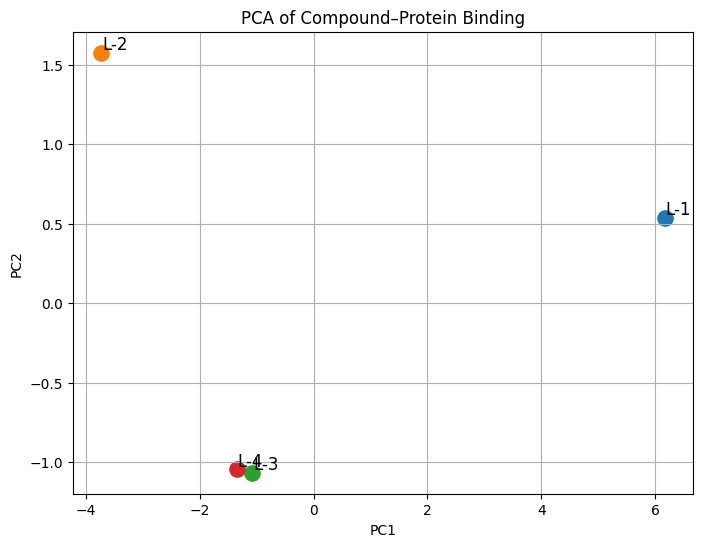

In [41]:
# ============================================================
# PCA of compound–protein binding data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ---------- 1. Load data ----------
# file_name = list(uploaded.keys())[0]  # uploaded from Colab
df = pd.read_csv('/content/F-fondbinding.csv')

print("Original Data:")
print(df.head())

# ---------- 2. Convert to matrix ----------
# Rows = compounds, Columns = proteins

matrix = df.pivot_table(
    index="compound_id",
    columns="protein_name",
    values="predicted_binding_score",
    fill_value=0
)

print("\nMatrix form:")
print(matrix)

# ---------- 3. Standardize ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(matrix)

# ---------- 4. PCA ----------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance:")
print(pca.explained_variance_ratio_)

# ---------- 5. Create PCA DataFrame ----------
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
pca_df["compound"] = matrix.index

print("\nPCA results:")
print(pca_df)

# ---------- 6. Plot ----------
plt.figure(figsize=(8,6))

for i, row in pca_df.iterrows():
    plt.scatter(row["PC1"], row["PC2"], s=120)
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, row["compound"], fontsize=12)

plt.title("PCA of Compound–Protein Binding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.show()